In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/Indian_Kids_Screen_Time.csv')

In [3]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


In [6]:
print(df.head())

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN          Urban  
4     Poor Sleep, Anx

In [4]:
print(df.tail())

      Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
9707   17    Male                      3.26     Smartphone   
9708   17  Female                      4.43     Smartphone   
9709   16    Male                      5.62     Smartphone   
9710   17    Male                      5.60             TV   
9711   15  Female                      6.12             TV   

      Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
9707                        True                               0.44   
9708                        True                               0.40   
9709                        True                               0.39   
9710                        True                               0.43   
9711                        True                               0.33   

                       Health_Impacts Urban_or_Rural  
9707                       Poor Sleep          Urban  
9708                       Poor Sleep          Rural  
9709  Poor Sleep, Eye Strain, Anxie

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Age                                9712 non-null   int64   
 1   Gender                             9712 non-null   object  
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64 
 3   Primary_Device                     9712 non-null   object  
 4   Exceeded_Recommended_Limit         9712 non-null   bool    
 5   Educational_to_Recreational_Ratio  9712 non-null   float64 
 6   Health_Impacts                     6494 non-null   object  
 7   Urban_or_Rural                     9712 non-null   object  
 8   Age_band                           9712 non-null   category
 9   Screen_Time_Level                  9486 non-null   category
dtypes: bool(1), category(2), float64(2), int64(1), object(4)
memory usage: 560.0+ KB
None


In [3]:
print(df.isnull().sum())

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64


In [10]:
print(df.shape)

(9712, 8)


 There are total 9712 rows and 8 columns in the dataset

DATA CLEANING PHASE

In [4]:
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')

In [5]:
df['Gender'] = df['Gender'].str.strip()
df['Primary_Device'] = df['Primary_Device'].str.strip()
df['Urban_or_Rural'] = df['Urban_or_Rural'].str.strip()

FEATURE ENGINEERING PHASE

CREATING AGE BANDS :-

In [3]:
df["Age_band"]= pd.cut(df["Age"],bins=[0,10,15,18],labels=["8-10","11-15","16-18"])

In [14]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_band
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,11-15
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,11-15
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,16-18
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,11-15
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,11-15
...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,16-18
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,16-18
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,16-18
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,16-18


CREATING SCREEN TIME LEVEL:-

In [4]:
df["Screen_Time_Level"]= pd.cut(df["Avg_Daily_Screen_Time_hr"],bins=[0,2,4,6,24],labels=["Low","Moderate","High","Very high"])

In [16]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_band,Screen_Time_Level
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,11-15,Moderate
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,11-15,High
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,16-18,Moderate
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,11-15,Low
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,11-15,High
...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,16-18,Moderate
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,16-18,High
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,16-18,High
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,16-18,High


SAVING PREPROCESSED FILE

In [8]:
df.to_csv('../data/Preprocessed.csv', index=False)

 BIVARIATE VISUALIZATIONS

Comparing Avg Screentime by Age band

C:\Users\HP\AppData\Local\Temp\ipykernel_24304\1614382233.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_avg = df.groupby("Age_band")["Avg_Daily_Screen_Time_hr"].mean()


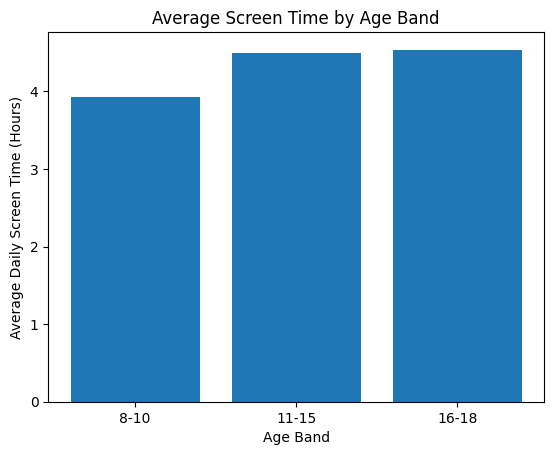

In [5]:
# Group by Age Band and calculate mean screen time
age_avg = df.groupby("Age_band")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
plt.bar(age_avg.index, age_avg.values)

plt.xlabel("Age Band")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.title("Average Screen Time by Age Band")

plt.show()

Comparison between avg screentime by gender

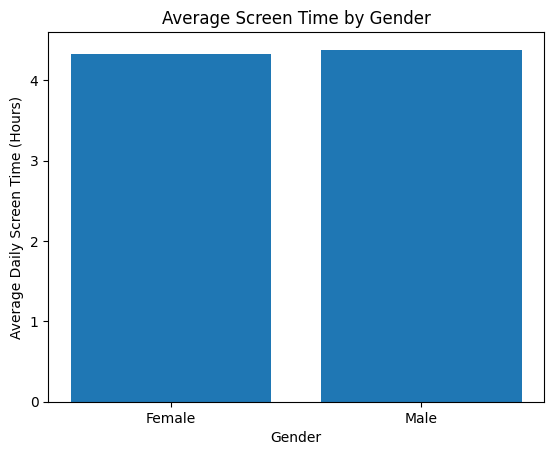

In [3]:
gender_avg = df.groupby("Gender")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
plt.bar(gender_avg.index, gender_avg.values)

plt.xlabel("Gender")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.title("Average Screen Time by Gender")

plt.show()

Comaparison between avg screen time and Location(urban/rural)

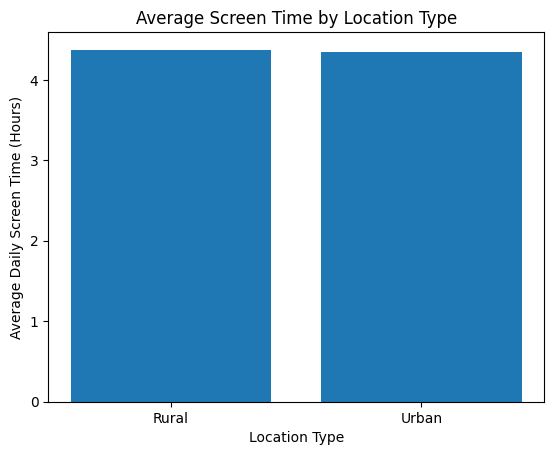

In [4]:
location_avg = df.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
plt.bar(location_avg.index, location_avg.values)

plt.xlabel("Location Type")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.title("Average Screen Time by Location Type")

plt.show()

UNIVARIATE ANALYSIS for Age band

In [7]:
print(df["Age_band"].value_counts())

Age_band
11-15    4403
8-10     2674
16-18    2635
Name: count, dtype: int64


therefore there are 2674 kids in the age band of 8-10 years old, 4403 kids in 11-15 yrs age band and 2635 kids into the 16-18yrs age band

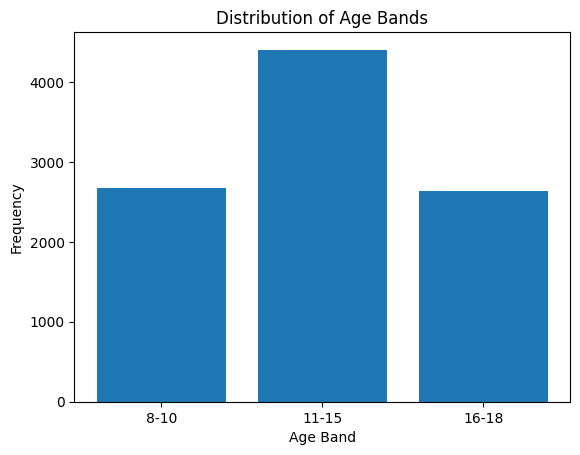

In [13]:
age_counts = df["Age_band"].value_counts().sort_index()

plt.figure()
plt.bar(age_counts.index, age_counts.values)

plt.xlabel("Age Band")
plt.ylabel("Frequency")
plt.title("Distribution of Age Bands")

plt.show()

UNIVARIATE ANALYSIS FOR SCREEN TIME LEVEL

In [17]:
print(df["Screen_Time_Level"].value_counts())

Screen_Time_Level
High         4596
Moderate     2930
Very high    1354
Low           606
Name: count, dtype: int64


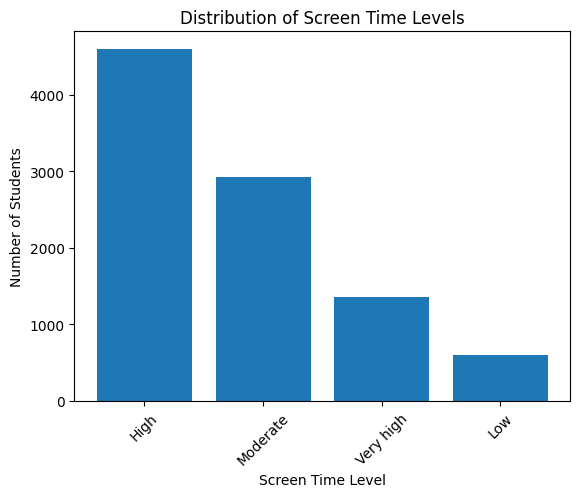

In [14]:
screen_counts = df["Screen_Time_Level"].value_counts()

plt.figure()
plt.bar(screen_counts.index, screen_counts.values)

plt.xlabel("Screen Time Level")
plt.ylabel("Number of Students")
plt.title("Distribution of Screen Time Levels")

plt.xticks(rotation=45)
plt.show()

AVG DAILY SCREEN TIME PER HOUR

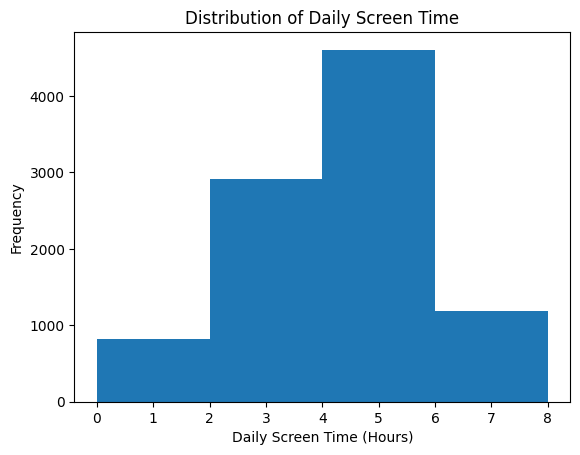

In [7]:
plt.figure()
plt.hist(df["Avg_Daily_Screen_Time_hr"], bins=[0,2,4,6,8])

plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Screen Time")

plt.show()

this means Most kids are spending between 4 to 6 hours daily on screens, Around 4500 kids are spending time on screen between 4 to 6 hrs.

Distribution across primary devices

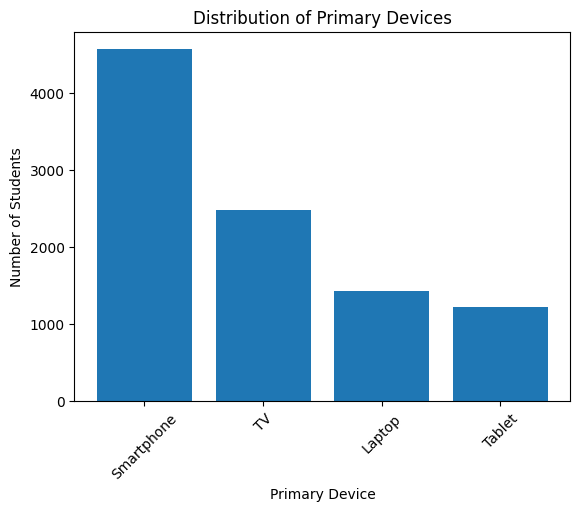

In [18]:
device_counts = df["Primary_Device"].value_counts()

plt.figure()
plt.bar(device_counts.index, device_counts.values)

plt.xlabel("Primary Device")
plt.ylabel("Number of Students")
plt.title("Distribution of Primary Devices")

plt.xticks(rotation=45)
plt.show()

SCREEN TIME VARIATION ACROSS GENDER (boxplot)

C:\Users\HP\AppData\Local\Temp\ipykernel_24304\2013133304.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male, female], labels=["Male", "Female"])


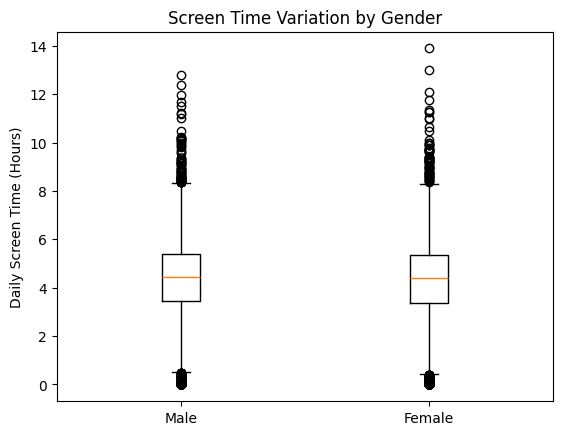

In [8]:
male = df[df["Gender"] == "Male"]["Avg_Daily_Screen_Time_hr"]
female = df[df["Gender"] == "Female"]["Avg_Daily_Screen_Time_hr"]

plt.figure()
plt.boxplot([male, female], labels=["Male", "Female"])

plt.ylabel("Daily Screen Time (Hours)")
plt.title("Screen Time Variation by Gender")

plt.show()

Screen time is almost similar for both genders, but the outliers says that quite amount of females are towards the excessive range of screen time

SCREEN TIME VARIATION ACROSS LOCATION (Boxplot)

C:\Users\HP\AppData\Local\Temp\ipykernel_24304\4180765004.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([urban, rural], labels=["Urban", "Rural"])


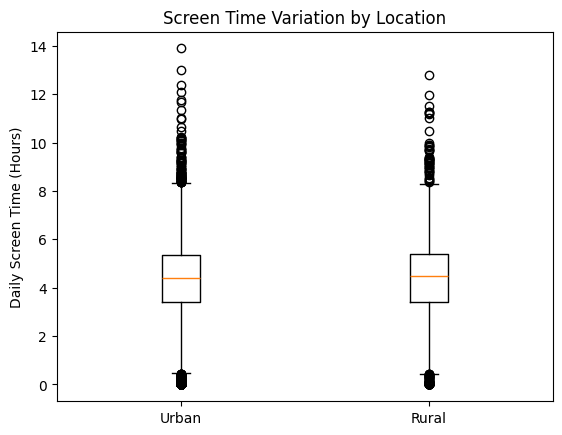

In [9]:
urban = df[df["Urban_or_Rural"] == "Urban"]["Avg_Daily_Screen_Time_hr"]
rural = df[df["Urban_or_Rural"] == "Rural"]["Avg_Daily_Screen_Time_hr"]

plt.figure()
plt.boxplot([urban, rural], labels=["Urban", "Rural"])

plt.ylabel("Daily Screen Time (Hours)")
plt.title("Screen Time Variation by Location")

plt.show()

though a minimal difference between the locations but still rural appears to be slightly higher than urban. but the extreme outliers are more in urban category

DEVICE-BASED ANALYSIS

Screen time by primary device

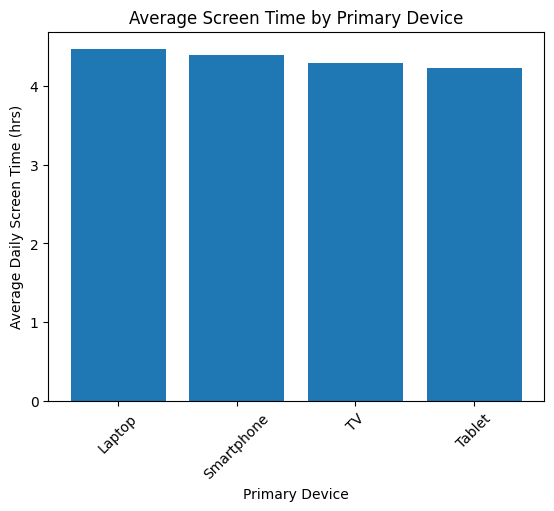

In [5]:
device_avg = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
plt.bar(device_avg.index, device_avg.values)

plt.xlabel("Primary Device")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.title("Average Screen Time by Primary Device")

plt.xticks(rotation=45)
plt.show()

On average, screen time does not vary drastically across devices.All values are between 4.2 to 4.5 hours.

<Figure size 640x480 with 0 Axes>

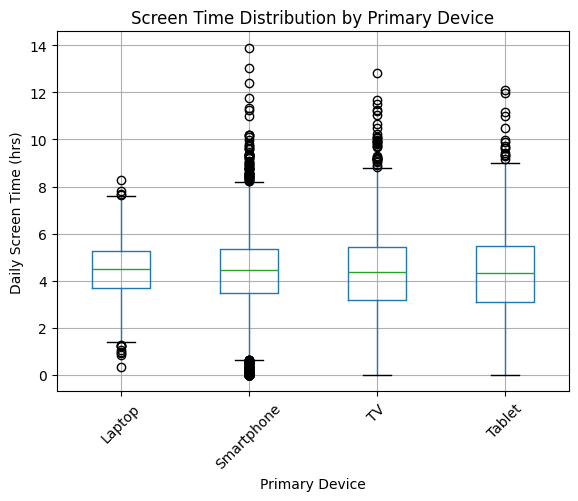

In [6]:
plt.figure()

df.boxplot(column="Avg_Daily_Screen_Time_hr",
           by="Primary_Device")

plt.xlabel("Primary Device")
plt.ylabel("Daily Screen Time (hrs)")
plt.title("Screen Time Distribution by Primary Device")

plt.suptitle("")   # removes default extra title
plt.xticks(rotation=45)

plt.show()

While the median screen time remains similar across devices, smartphone and TV users demonstrate higher variability and more extreme usage cases. This suggests that portable and entertainment-focused devices may contribute more significantly to high-risk screen exposure patterns.

It can also be seen that the Smartphone usage shows both minimal and excessive usage patterns, indicating diverse behavioral groups.

USAGE BALANCE BY AGE BAND

C:\Users\HP\AppData\Local\Temp\ipykernel_18304\3874557204.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_usage = df.groupby("Age_band")["Educational_to_Recreational_Ratio"].mean()


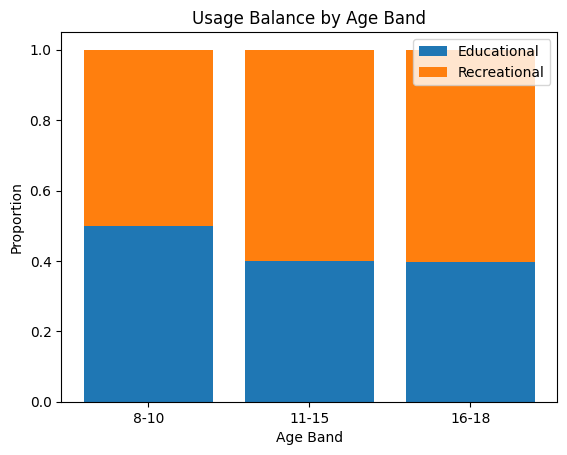

In [9]:
age_usage = df.groupby("Age_band")["Educational_to_Recreational_Ratio"].mean()
educational = age_usage
recreational = 1 - age_usage
plt.figure()

plt.bar(age_usage.index, educational, label="Educational")
plt.bar(age_usage.index, recreational, bottom=educational, label="Recreational")

plt.xlabel("Age Band")
plt.ylabel("Proportion")
plt.title("Usage Balance by Age Band")
plt.legend()

plt.show()

This indicates a clear shift in screen usage patterns with age. While younger children demonstrate a balanced educational-recreational usage, adolescents show a higher proportion of recreational engagement, suggesting increasing autonomy and entertainment-oriented digital behavior.

ANALYSING EDUCATION TO RECREATIONAL RATIO BY GENDER

In [5]:
df["Educational_Time"] = (df["Educational_to_Recreational_Ratio"] / 
                         (1 + df["Educational_to_Recreational_Ratio"])) * df["Avg_Daily_Screen_Time_hr"]

df["Recreational_Time"] = (1 / 
                          (1 + df["Educational_to_Recreational_Ratio"])) * df["Avg_Daily_Screen_Time_hr"]

In [6]:
gender_usage = df.groupby("Gender")[["Educational_Time", "Recreational_Time"]].mean()
print(gender_usage)

        Educational_Time  Recreational_Time
Gender                                     
Female          1.280158           3.046863
Male            1.298945           3.078809


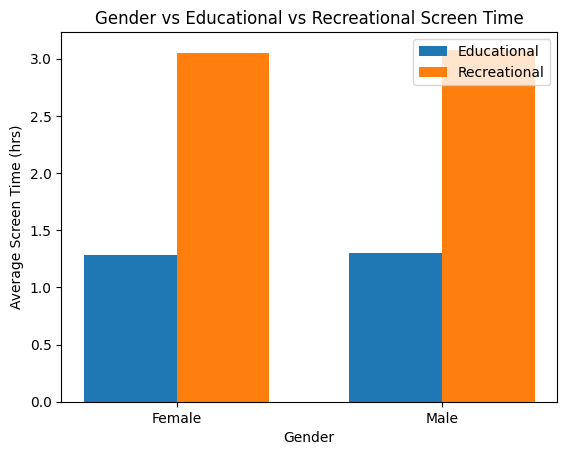

In [7]:
labels = gender_usage.index
edu = gender_usage["Educational_Time"]
rec = gender_usage["Recreational_Time"]

x = np.arange(len(labels))
width = 0.35

plt.figure()

plt.bar(x - width/2, edu, width, label="Educational")
plt.bar(x + width/2, rec, width, label="Recreational")

plt.xticks(x, labels)

plt.xlabel("Gender")
plt.ylabel("Average Screen Time (hrs)")
plt.title("Gender vs Educational vs Recreational Screen Time")

plt.legend()

plt.show()

Both male and female children spend more time on recreational activities than educational ones.

Identifying  highest risk device 
(% Exceeding recommended limit by device)

In [5]:
df["Exceeded_Recommended_Limit"] = df["Exceeded_Recommended_Limit"].astype(int)

here true=1 and false=0

In [6]:
device_risk = df.groupby("Primary_Device")["Exceeded_Recommended_Limit"].mean() * 100

In [7]:
device_risk = device_risk.sort_values(ascending=False)   #sort to rank

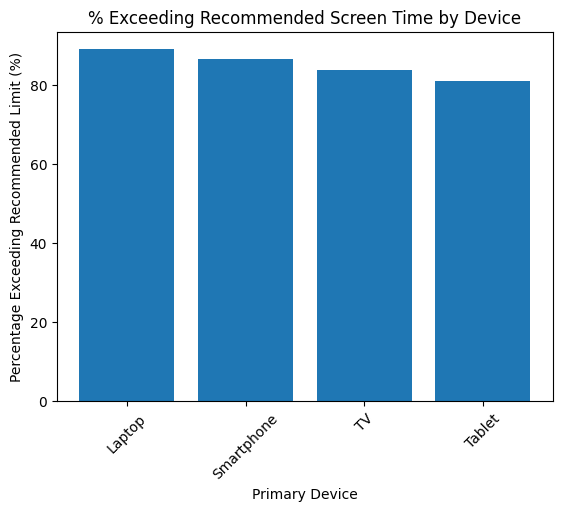

In [8]:
plt.figure()
plt.bar(device_risk.index, device_risk.values)

plt.xlabel("Primary Device")
plt.ylabel("Percentage Exceeding Recommended Limit (%)")
plt.title("% Exceeding Recommended Screen Time by Device")

plt.xticks(rotation=45)
plt.show()

The ranked bar chart indicates that a high proportion of users exceed recommended screen time limits across all devices, with laptops showing the highest percentage. However, the variation between devices is relatively small, suggesting that excessive screen exposure is a widespread issue rather than device-specific.

PERCENTAGE OF KIDS EXCEEDING LIMIT BY AGE BAND

In [7]:
age_exceed = df.groupby("Age_band")["Exceeded_Recommended_Limit"].mean() * 100

C:\Users\HP\AppData\Local\Temp\ipykernel_5020\3600821714.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_exceed = df.groupby("Age_band")["Exceeded_Recommended_Limit"].mean() * 100


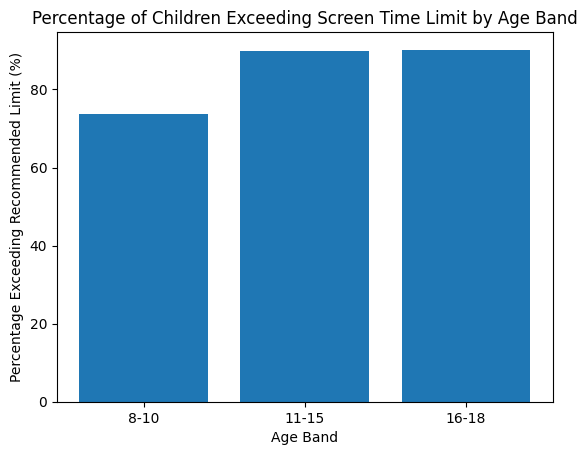

In [8]:
plt.figure()

plt.bar(age_exceed.index, age_exceed.values)

plt.xlabel("Age Band")
plt.ylabel("Percentage Exceeding Recommended Limit (%)")
plt.title("Percentage of Children Exceeding Screen Time Limit by Age Band")

plt.show()

Overall, most children in every age group are exceeding the recommended screen time limit, with the highest percentage seen in older age groups.

SCREEN TIME VS HEALTH IMPACT

In [9]:
df["Health_Risk_Flag"] = df["Health_Impacts"].notna().astype(int)

In [10]:
health_avg = df.groupby("Health_Risk_Flag")["Avg_Daily_Screen_Time_hr"].mean()

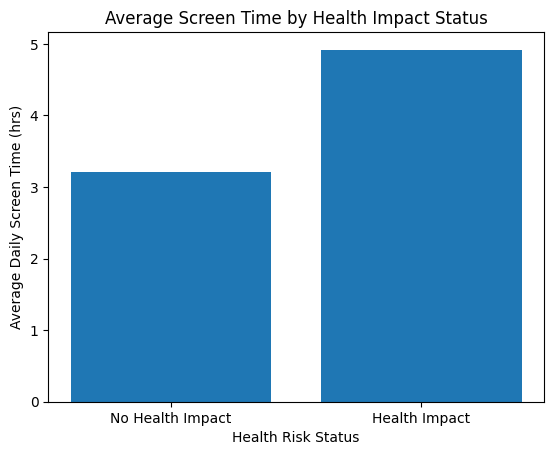

In [11]:
plt.figure()
plt.bar(["No Health Impact", "Health Impact"], health_avg.values)

plt.xlabel("Health Risk Status")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.title("Average Screen Time by Health Impact Status")

plt.show()

Children reporting health impacts spend significantly more time on screens than those without reported issues.

COHORT ANALYSIS

RELATION BETWEEN AGE BAND AND DEVICES

In [ ]:
cohort_table = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age_band",
    columns="Primary_Device",
    aggfunc="mean"
)


C:\Users\HP\AppData\Local\Temp\ipykernel_16640\1222594896.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cohort_table = df.pivot_table(


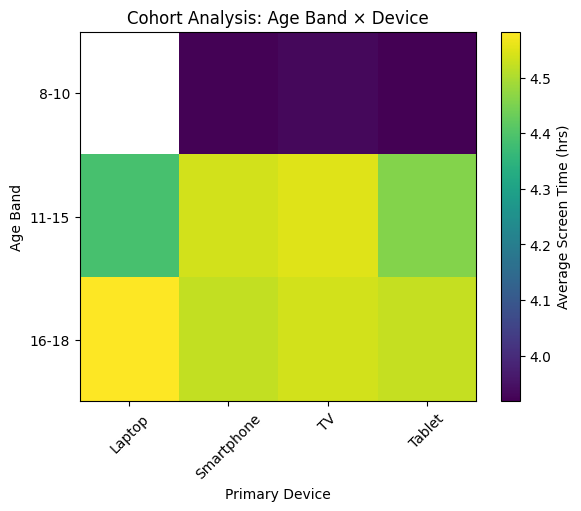

In [14]:
plt.figure()

plt.imshow(cohort_table, aspect="auto")

plt.colorbar(label="Average Screen Time (hrs)")

plt.xticks(range(len(cohort_table.columns)), cohort_table.columns, rotation=45)
plt.yticks(range(len(cohort_table.index)), cohort_table.index)

plt.xlabel("Primary Device")
plt.ylabel("Age Band")
plt.title("Cohort Analysis: Age Band × Device")

plt.show()

The cohort heatmap reveals a clear upward trend in screen time with increasing age across all device categories. The 16–18 age group exhibits the highest average screen exposure, particularly for laptops and smartphones, indicating greater digital engagement among older adolescents.

HEALTH IMPACT X SCREEN TIME BY AGE BAND

In [12]:
cohort_table = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age_band",
    columns="Health_Impacts",
    aggfunc="mean"
)

C:\Users\HP\AppData\Local\Temp\ipykernel_21588\3976696057.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cohort_table = df.pivot_table(


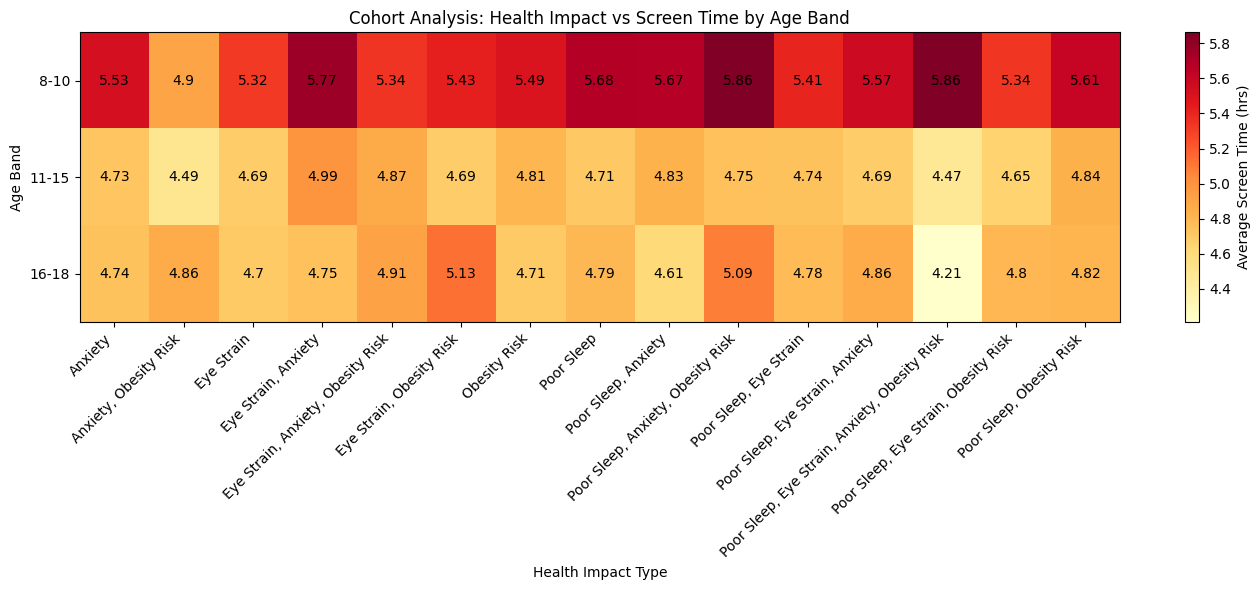

In [15]:

data = cohort_table.values

plt.figure(figsize=(14,6))

plt.imshow(data, cmap="YlOrRd", aspect="auto")

for i in range(len(cohort_table.index)):
    for j in range(len(cohort_table.columns)):
        plt.text(j, i,
                 round(data[i, j],2),
                 ha="center",
                 va="center",
                 color="black")
        
plt.xticks(range(len(cohort_table.columns)),
           cohort_table.columns,
           rotation=45,
           ha="right")

plt.yticks(range(len(cohort_table.index)),
           cohort_table.index)

plt.xlabel("Health Impact Type")
plt.ylabel("Age Band")

plt.title("Cohort Analysis: Health Impact vs Screen Time by Age Band")

plt.colorbar(label="Average Screen Time (hrs)")

plt.tight_layout()

plt.show()

The 8–10 age band consistently shows the highest average screen time, mostly between 5.3 to 5.8 hours across many health impact categories.

HEALTH IMPACT VS SCREEN TIME BY PRIMARY DEVICE
(For each device, how screen time differs between children with health impact vs without health impact)

In [23]:
cohort_table = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Primary_Device",
    columns="Health_Impacts",
    aggfunc="mean"
)

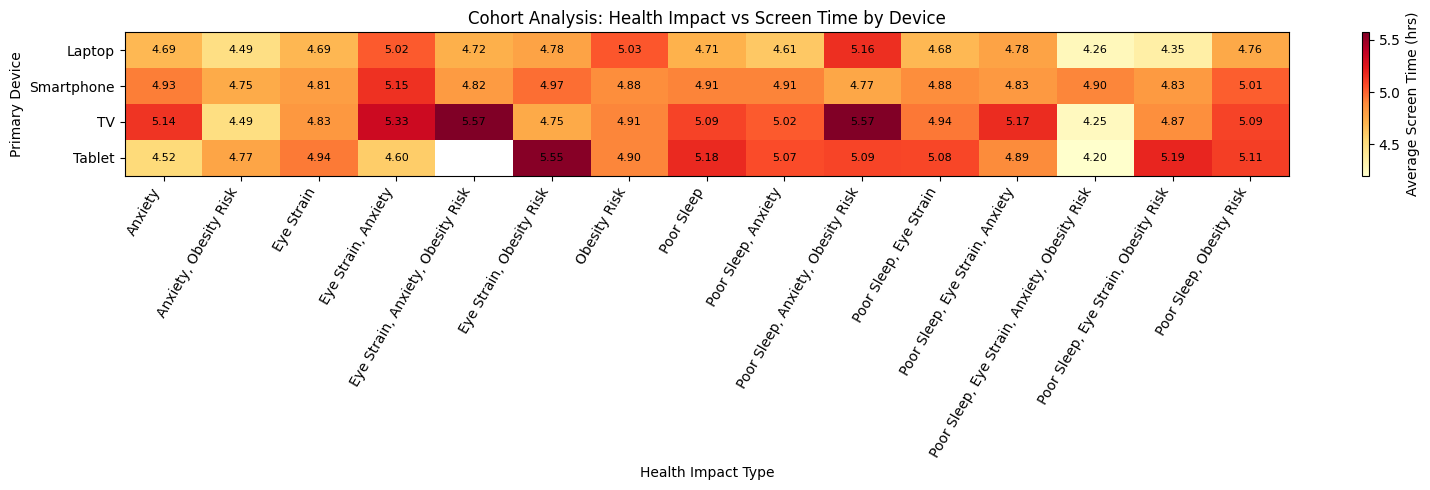

In [25]:
data = cohort_table.values

plt.figure(figsize=(16,5))

plt.imshow(data, cmap="YlOrRd", aspect="auto")

plt.xticks(
    range(len(cohort_table.columns)),
    cohort_table.columns,
    rotation=60,
    ha="right"
)

plt.yticks(
    range(len(cohort_table.index)),
    cohort_table.index
)

plt.xlabel("Health Impact Type")
plt.ylabel("Primary Device")
plt.title("Cohort Analysis: Health Impact vs Screen Time by Device")

plt.colorbar(label="Average Screen Time (hrs)")

# add numbers inside cells
for i in range(len(cohort_table.index)):
    for j in range(len(cohort_table.columns)):
        value = data[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.2f}",
                     ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

TV being the most primary device contributing to more health issues

GENDER VS SCREEN TIME GROUPED BY DEVICE

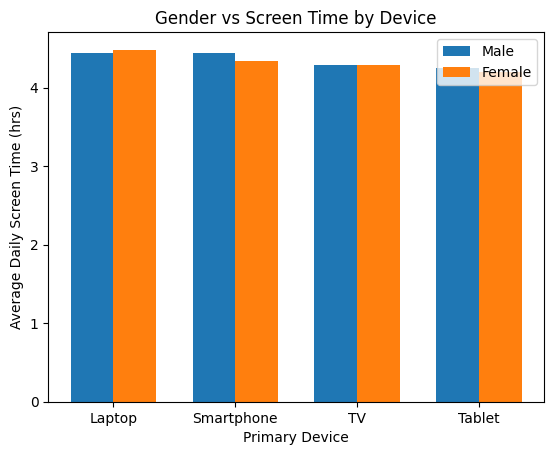

In [16]:
gender_device = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Primary_Device",
    columns="Gender",
    aggfunc="mean"
)

devices = gender_device.index
male = gender_device["Male"]
female = gender_device["Female"]

x = np.arange(len(devices))
width = 0.35

plt.figure()

plt.bar(x - width/2, male, width, label="Male")
plt.bar(x + width/2, female, width, label="Female")

plt.xlabel("Primary Device")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.title("Gender vs Screen Time by Device")

plt.xticks(x, devices)
plt.legend()

plt.show()

The analysis shows minimal gender differences in screen time across devices, suggesting that both male and female children exhibit similar digital consumption patterns, with only slight variations in laptop and smartphone usage.

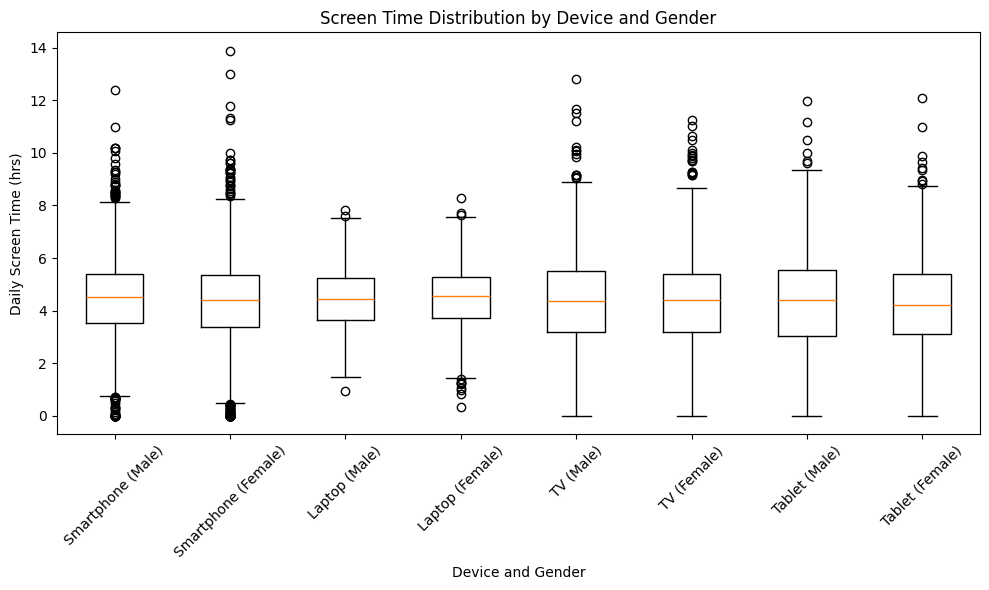

In [22]:
devices = df["Primary_Device"].unique()

data = []
labels = []

for d in devices:
    male = df[(df["Primary_Device"] == d) & (df["Gender"] == "Male")]["Avg_Daily_Screen_Time_hr"]
    female = df[(df["Primary_Device"] == d) & (df["Gender"] == "Female")]["Avg_Daily_Screen_Time_hr"]
    
    data.append(male)
    data.append(female)
    
    labels.append(d + " (Male)")
    labels.append(d + " (Female)")

plt.figure(figsize=(10,6))

plt.boxplot(data)

plt.xticks(range(1, len(labels)+1), labels, rotation=45)

plt.xlabel("Device and Gender")
plt.ylabel("Daily Screen Time (hrs)")
plt.title("Screen Time Distribution by Device and Gender")

plt.tight_layout()

plt.show()

the primary device contributing to more screen time are smartphones and tv's, females having dominance in smart phone usage whereas males dominates in TV usage

LOCATION VS SCREEN TIME GROUPED BY DEVICE

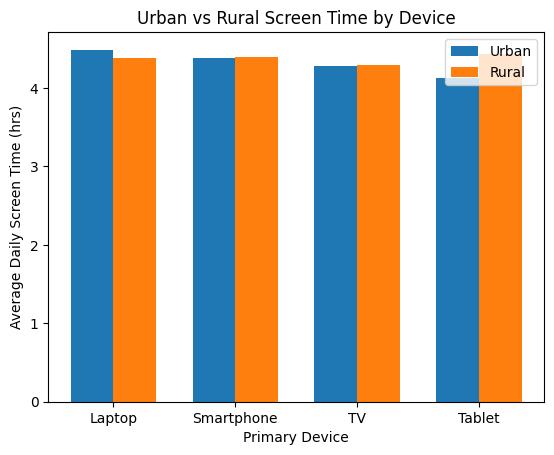

In [18]:
location_device = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Primary_Device",
    columns="Urban_or_Rural",  
    aggfunc="mean"
)

devices = location_device.index
urban = location_device["Urban"]
rural = location_device["Rural"]

x = np.arange(len(devices))
width = 0.35

plt.figure()

plt.bar(x - width/2, urban, width, label="Urban")
plt.bar(x + width/2, rural, width, label="Rural")

plt.xlabel("Primary Device")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.title("Urban vs Rural Screen Time by Device")

plt.xticks(x, devices)
plt.legend()

plt.show()

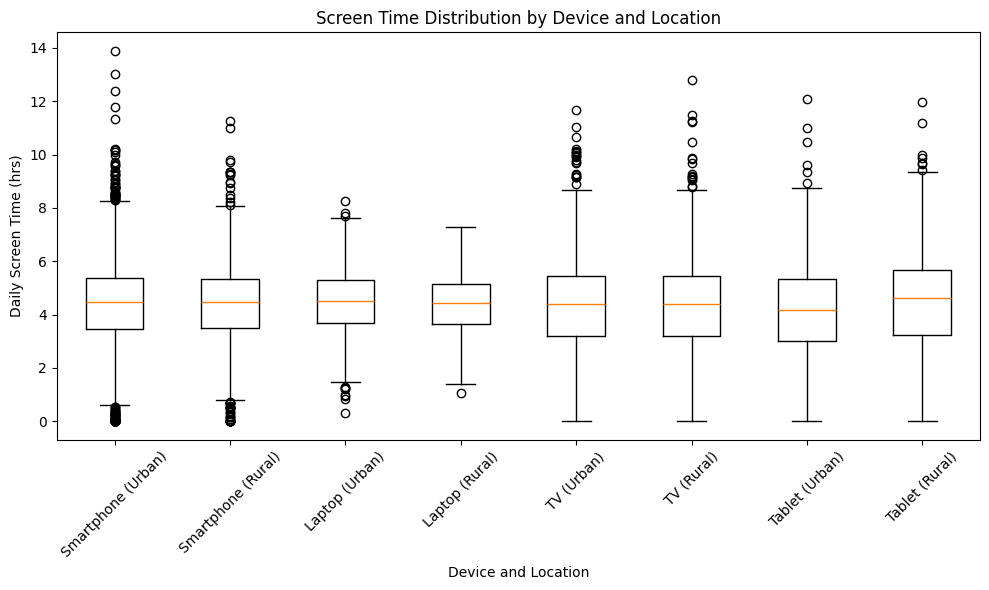

In [21]:
devices = df["Primary_Device"].unique()

data = []
labels = []

for d in devices:
    urban = df[(df["Primary_Device"] == d) & (df["Urban_or_Rural"] == "Urban")]["Avg_Daily_Screen_Time_hr"]
    rural = df[(df["Primary_Device"] == d) & (df["Urban_or_Rural"] == "Rural")]["Avg_Daily_Screen_Time_hr"]
    
    data.append(urban)
    data.append(rural)
    
    labels.append(d + " (Urban)")
    labels.append(d + " (Rural)")

plt.figure(figsize=(10,6))

plt.boxplot(data)

plt.xticks(range(1, len(labels)+1), labels, rotation=45)
plt.xlabel("Device and Location")
plt.ylabel("Daily Screen Time (hrs)")
plt.title("Screen Time Distribution by Device and Location")

plt.tight_layout()
plt.show()

The distribution suggests that rural children may spend slightly more time watching television, indicating that TV remains an important entertainment medium in rural households compared to urban areas where smartphones dominate screen usage.

The shift from television dominance in rural areas to smartphone dominance in urban areas reflects differences in device accessibility and digital infrastructure.
